### Agentic AI and Open Source Frameworks
- Objectives
    - core traits of Agentic AI systems
    - Benifits and challenges of multi-agent architecture
    - strengths and use cases of popular open-source frameoworks
    - when to apply each frameworks

- AI Agents
    - systems operate autonomously
    - make decison and take actions
    - accomplish goals
    - practive problem solvers
    - Navigate comples environments

- Key charactrestics of an AI agent

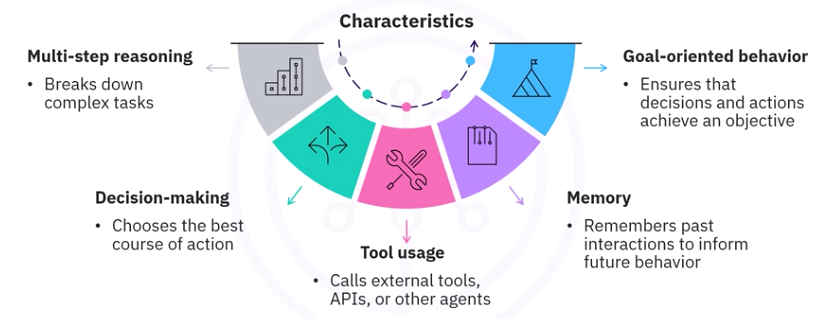

- AI agent is a shift form **reactive** to **proactive system**
- this is similar to a change from a calculator to a research assistent
    - calculator: response only to the input
    - research assistent: understand the goal, break it into steps, use tools to gather information and solves the problem.

- why frameworks

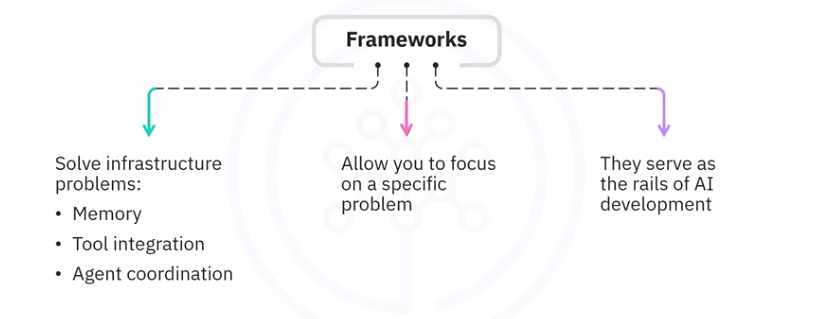

- Key benifits of Multi-Agent systems

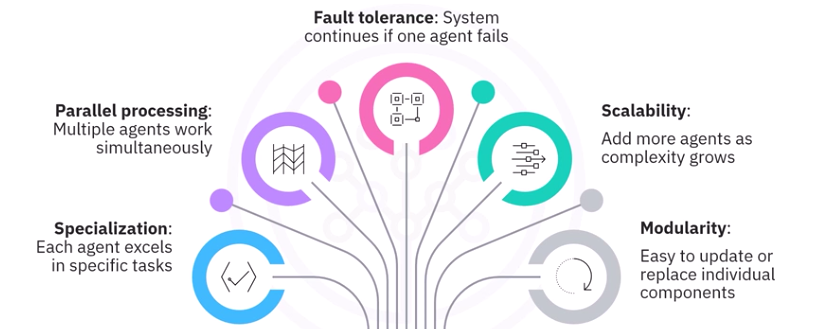

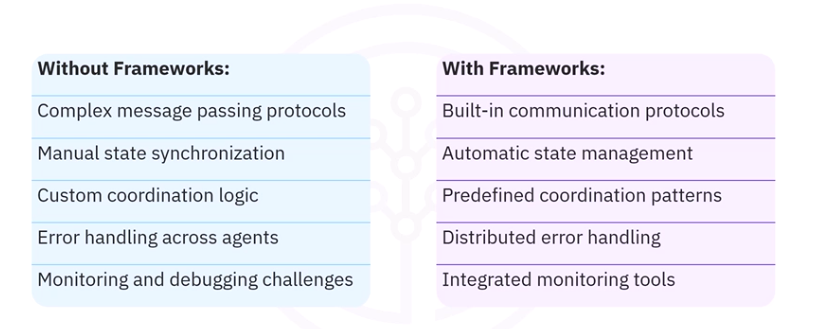

- Different agentic ai frameworks
    - CrewAI
    - LangGraph
    - AutoGen(AG2)
    - Pydantic AI
    - BeeAI

- **CrewAI**

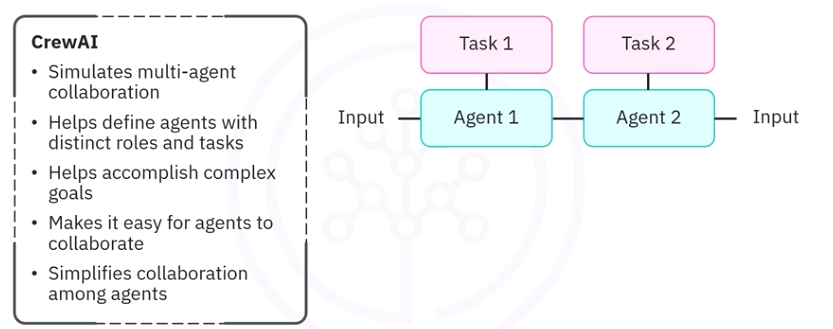

- **LangGraph**

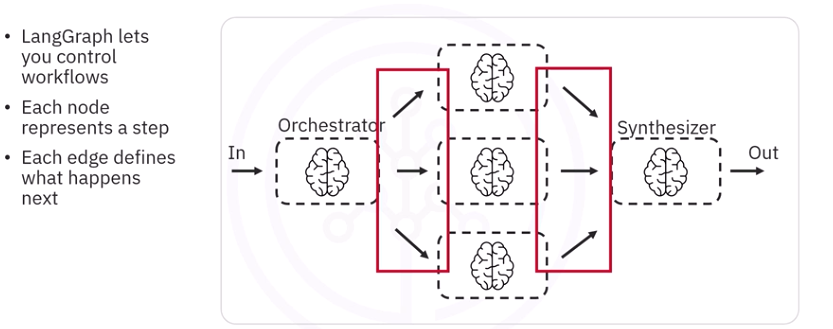

- Fine contorl over the workflow
- Define how information flow over nodes and edges

- advantages
    - great for complex workflows
    - Integrate LLMs, tools and LangChain
    - Use cases
        - multi-step processes
        - document workflows
        - decision trees

- **AutoGen**

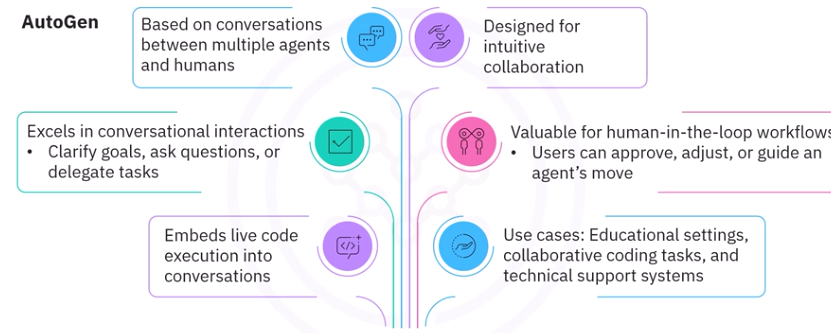

- **Pydantic AI**

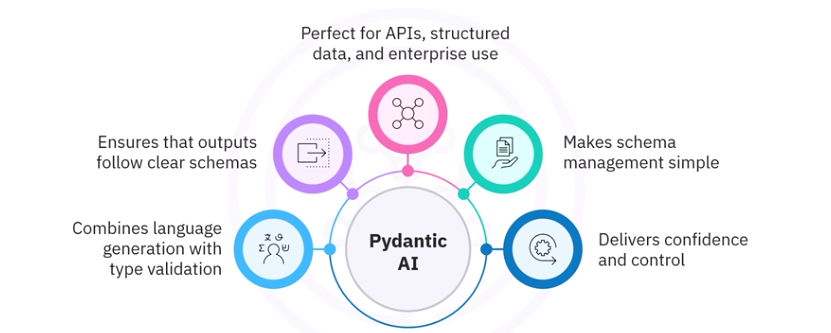

- **BeeAI**

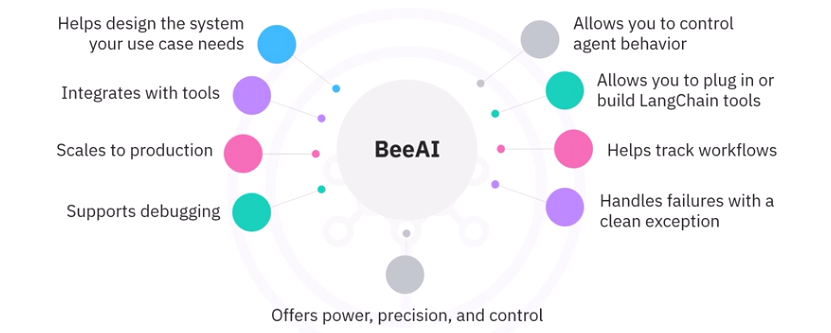

- comparison

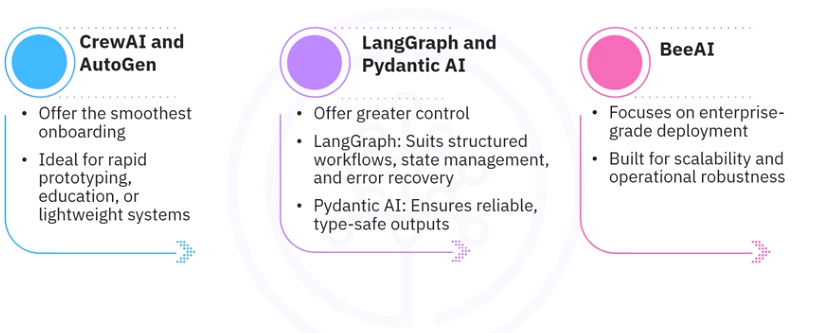

- Applications

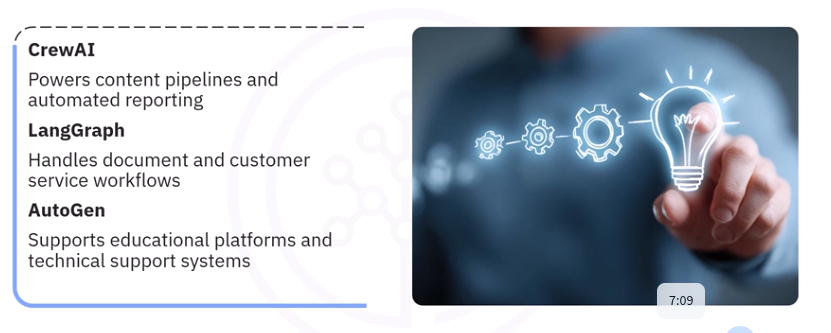

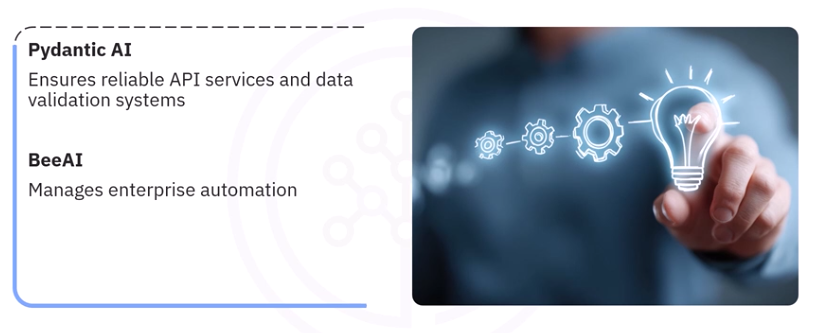







### Building AI Agents with Open Source Frameworks
- Objectives
    - Muliti Agent workflows on
        - CrewAI
        - LangGraph
        - AutoGent
        - BeeAI
    - How Agents are designed, assigned tasks, and coordinated with each framework
    - Code that defines workflows, agens and contorl logic
    - Compare real-world use cases and limitations across the 4 frameworks

### CrewAI
- Agentic framwork for assembling virtual experts
- each expert
    - plays a role
    - use tools
    - work towards a clear goal
    - collaborate and solve problem

- process
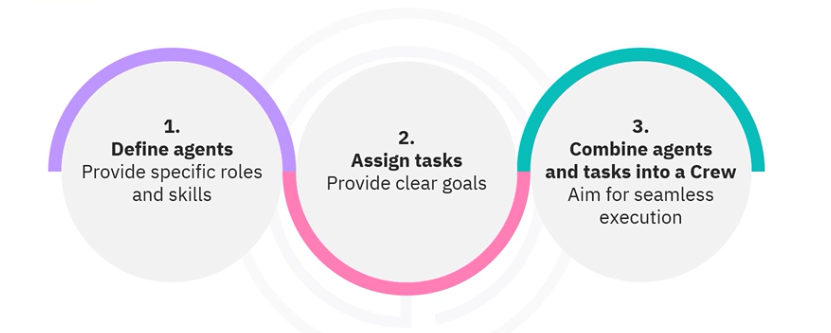

- Pipeline
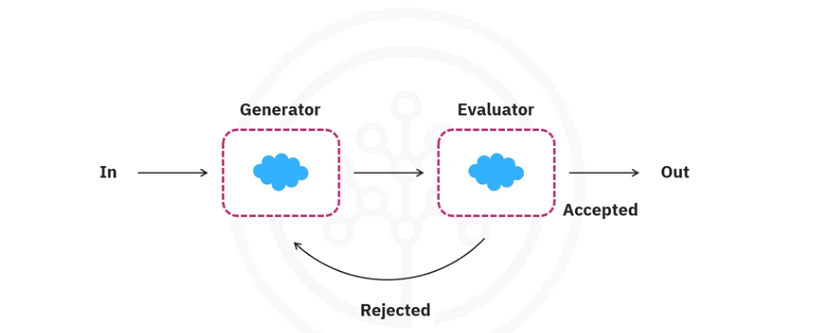

#### code
- setup the core environment
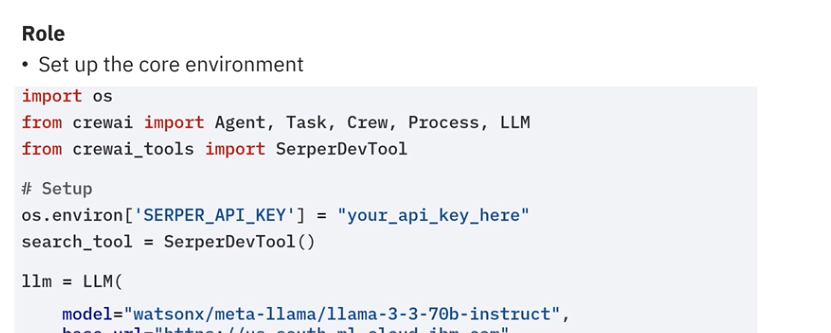
    - search_tool()

    - create a researcher and writer agent
    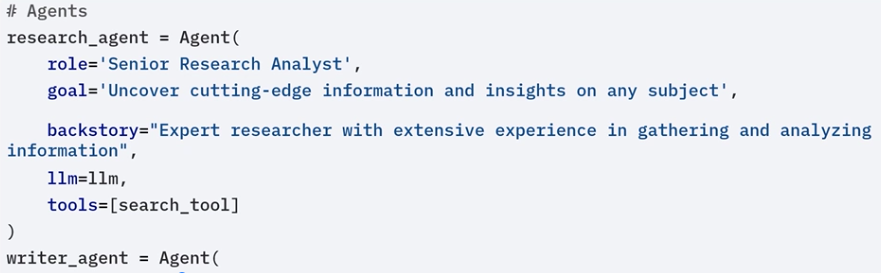
    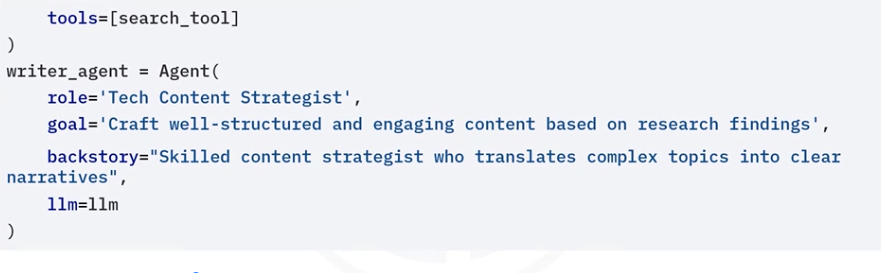

    - create task for each agent
    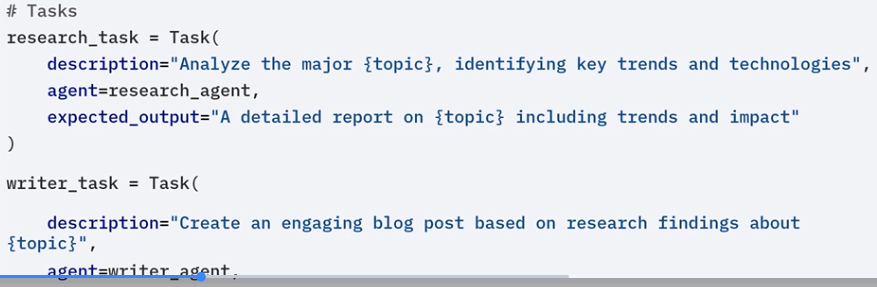

    - create a crew object combining agetns and tasks
    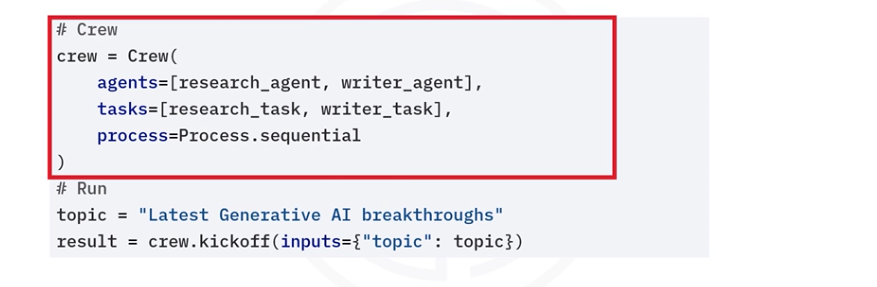

#### use cases
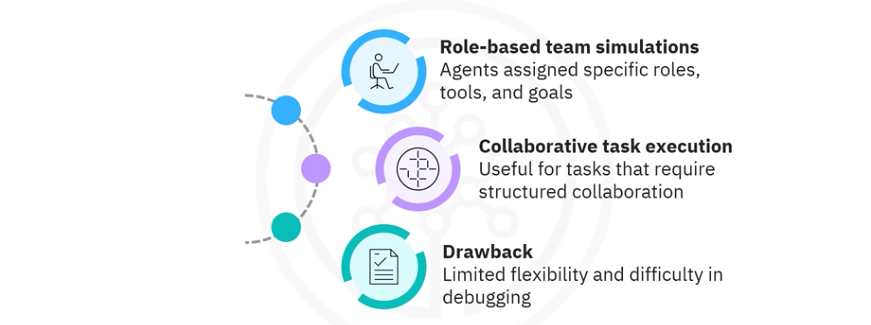

### LangGraph
- Lower-level framework for building custom agent workflows
- offers
    - Fine-grained control
    - Better debugging
    - Advanced memory
    - Error recovery
- ideal for complex structured apps

#### code
- environemt setup
- state sturucture to memory management
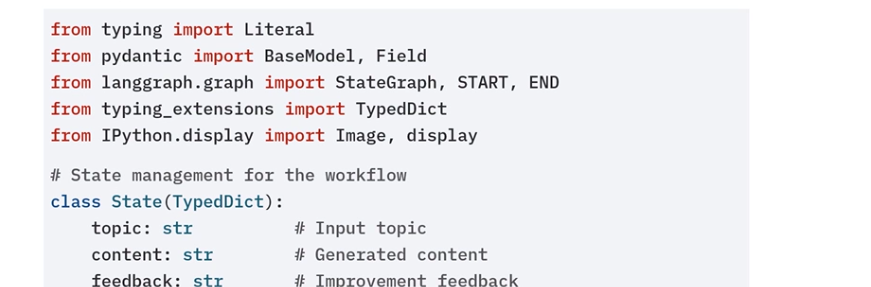

- schemea to define the model output (evaluator)
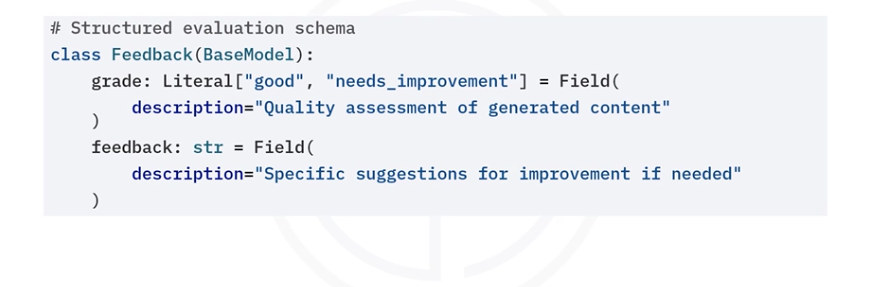

- Agents are nodes and graphs
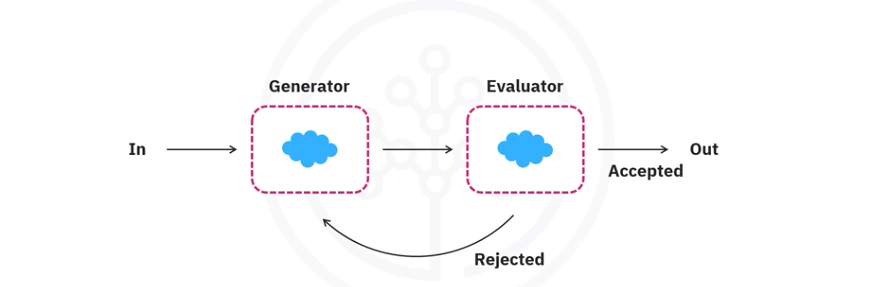

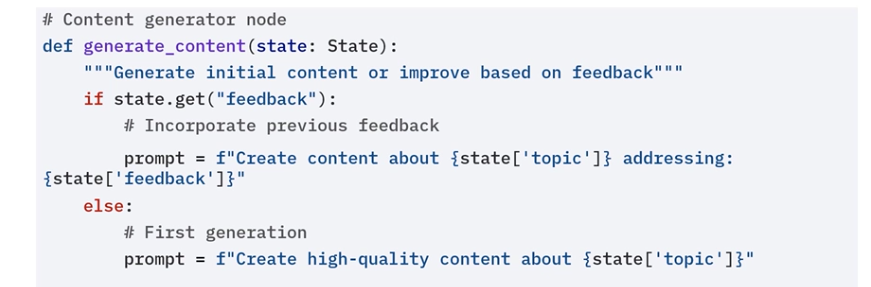
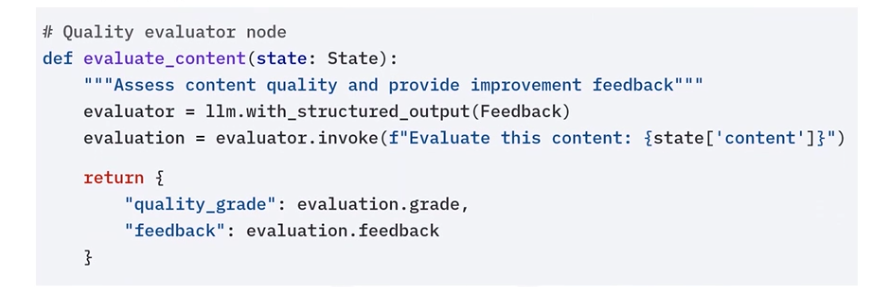

- router function (condtional node)
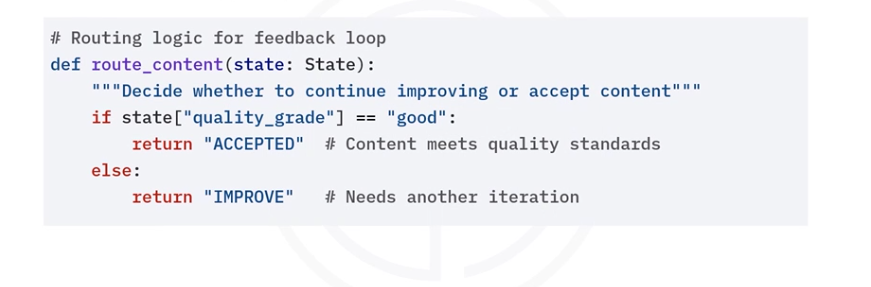

- Building graphs and compile the graph
- Langgraph is good for 
    - complex workflows
    - ideal for use-case require advance memory and structured workflows
    - also sutable fo appliations needing precise control over interaction between multiple agents

### AutoGen (AG2)
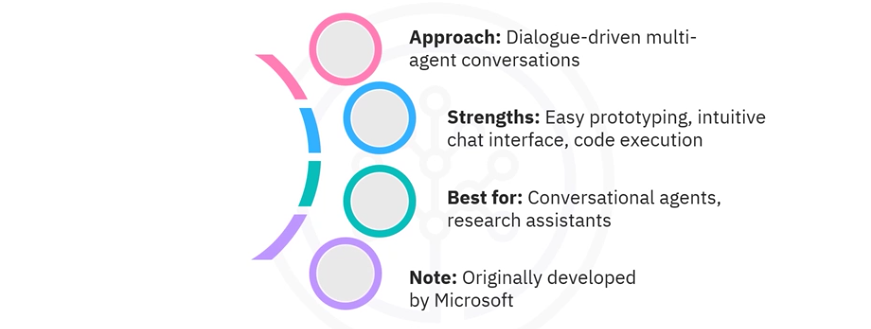
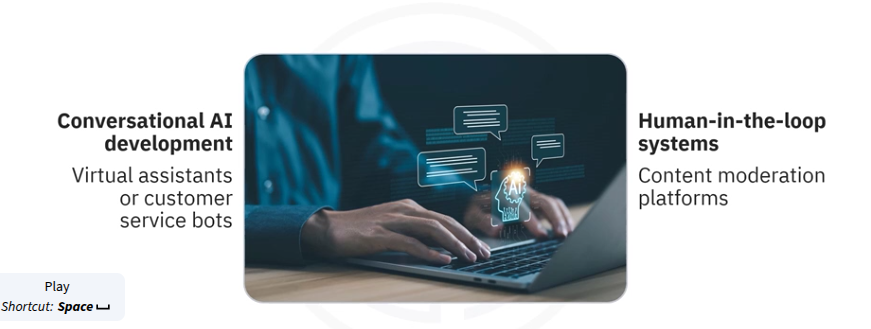

- use case
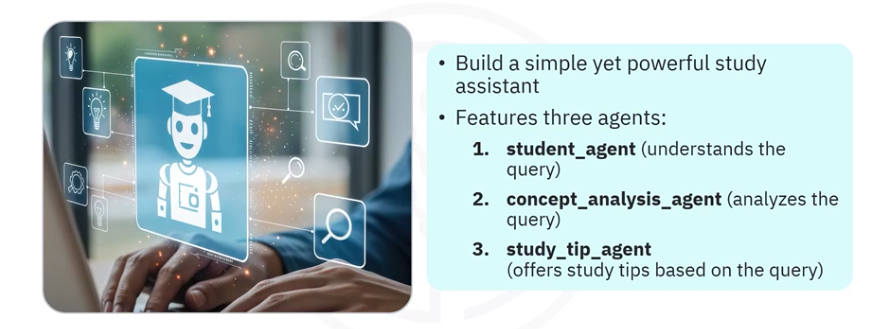

- code
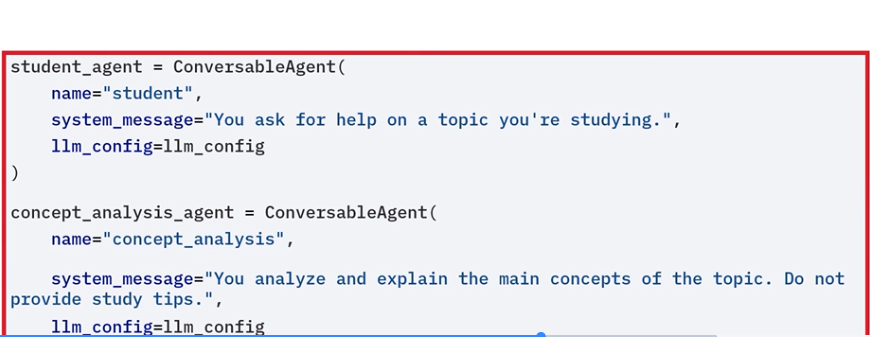
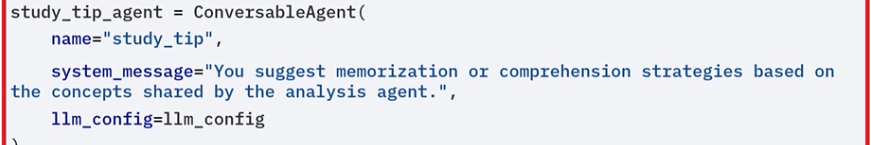

- orchestration of agent ineraction
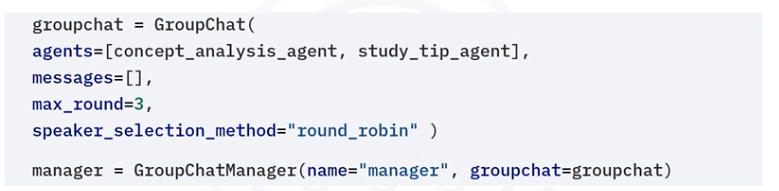
    - max_round: defines the number of truns
    - speaker_selection_method: the priority for speakers
        - "round_robin" equal amount of time

- user input
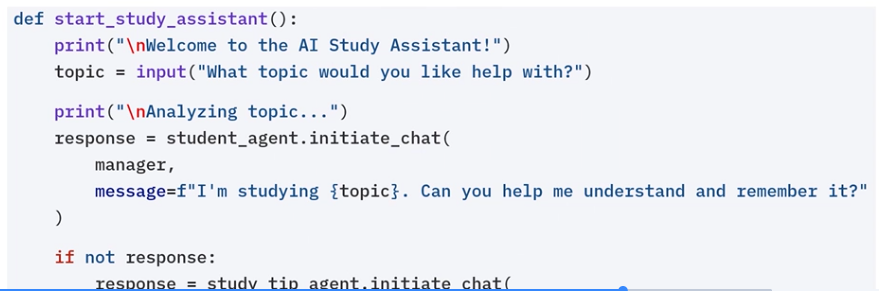
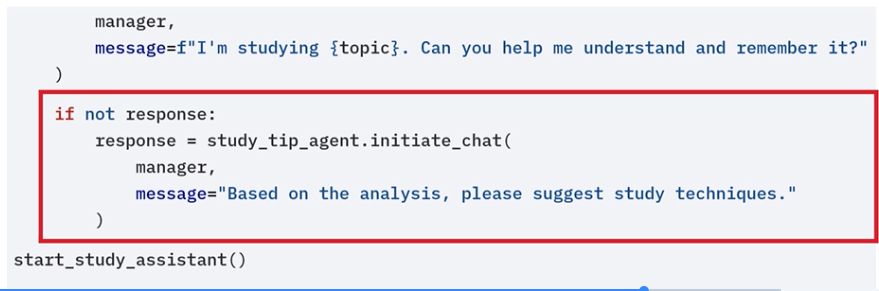
    


### BeeAI
- Modular agent workflow with integrated tools
- Example
    - Three-agent collaboration to generate a location report
    - Agents
        - Researcher: use Wikipeida for historical context
        - WeatherForecaster: use OpenMetro for live wether
        - DataSynthesizer: Fuses historical and weather data into a coherent summary

- install BeeAI framework and export libs
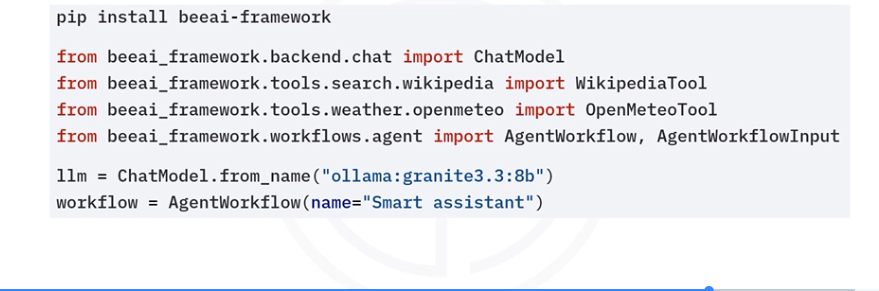

- add agent to workflow
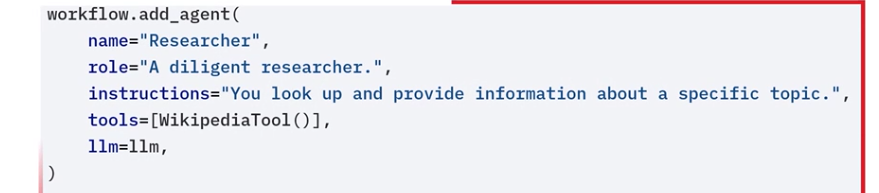
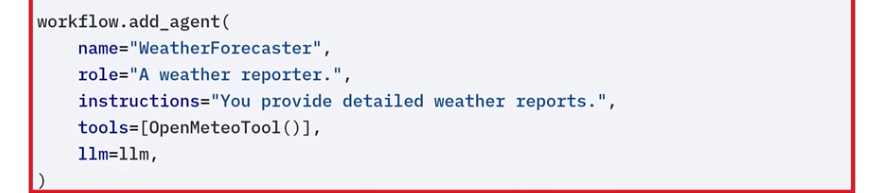
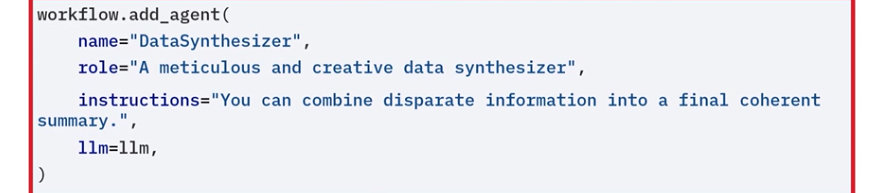

- Running workflow
    - can be run sequance or in parallel
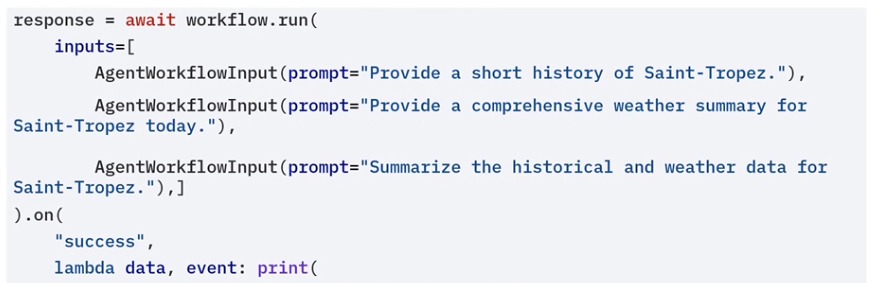
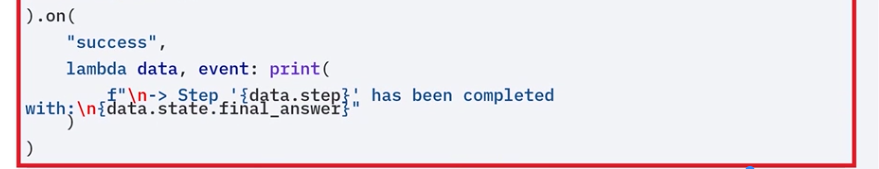


- final fused summary
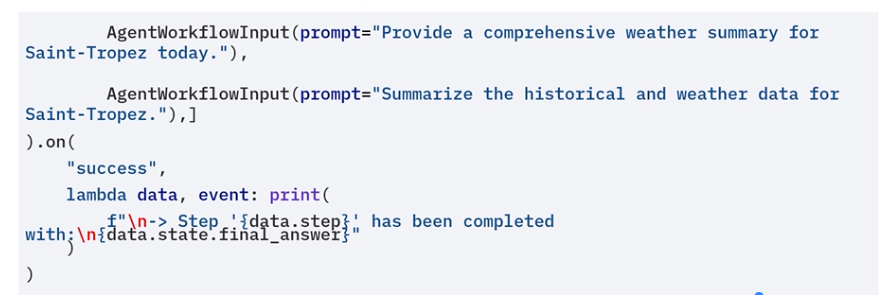

### Recap
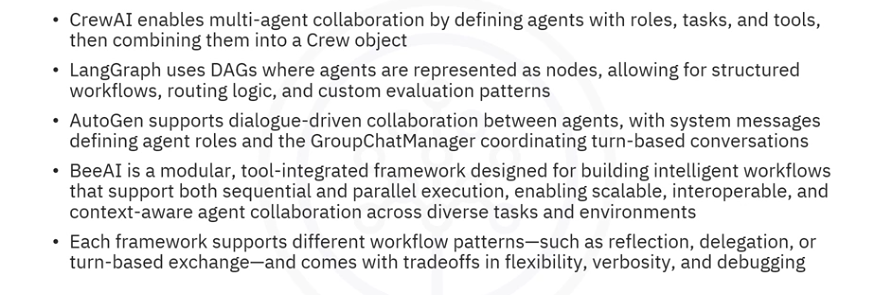


## AI System Design Patterns

### Essential Design Patterns
- Objectives
    - Sequential, routing, and Pralleliyation patterns for LLM workflows
    - Each pattern using LangGraph code examples
    - Interpret state variables, nodes, and workflow execution flow
    - output generated by each pattern from sample input

#### Sequential Design pattern
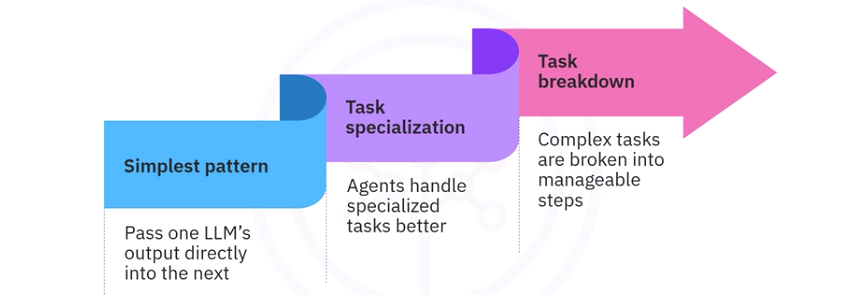

    - exmaple
    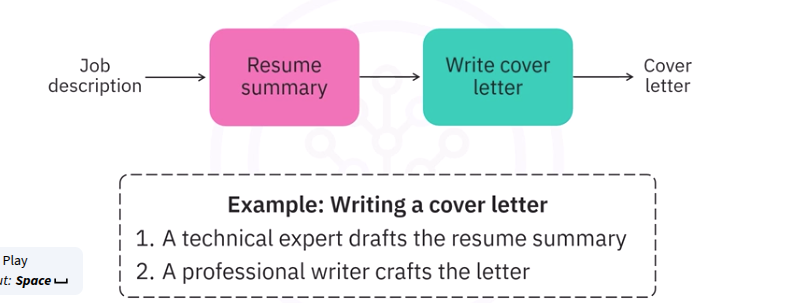

    - code

```python
import langgraph.graph import StateGraph, END, START
from typing import TypeDict
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model='gpt-4o-mini'
)

#create a ChainState object for commnication betwen agents
class ChainState(TypeDict):
    job_description: str
    resume_summary: str
    cover_letter:str

# create agents
def generate_resume_summary(state: ChainState)->ChainState:
    prompt = f"""
    You're a reusme assistent. Read the followign jon description and summariye the key qualifications and experience the ideal candiate should have, phrase as if from the perspective of a strong applicant's resume summary.

    Job Description: {state["job_description"]}
    """

    response = llm.invoke(prompt)
    return {**state, "resume_summary": response.content}

def generate_cover_letter(state: ChainState) -> ChainState:
    prompt = f"""
    You're a cover letter writing assitant, Using the resume sumary bewlo, write a professional and personalized cover letter for the following job.

    Resume Summary: {state[resume_summary]}

    Job Description: {state[job_description]}
    """

    response = llm.invoke(prompt)

    return {**state, "cover_letter": response.content}

# create workflow graph using ChainState as input
workflow = StateGraph(ChainState)
workflow.add_node("generate_resume_summary", generate_resume_summary)
workflow.add_node("generate_cover_letter", generate_cover_letter)

# to add edges
workflow.add_edge(START, "generate_resume_summary")
workflow.add_edge("generate_resume_summary", "generate_cover_letter")
workfow.add_edge("generate_cover_letter", END)

# compile the graph
app = workflow.compile()

input_state = {
    "job_description": ....
}

result = app.invoke(input_state)
```

#### Routing Design Pattern

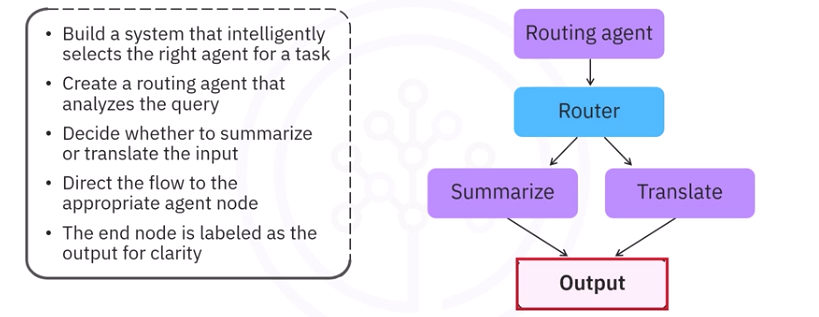

- example

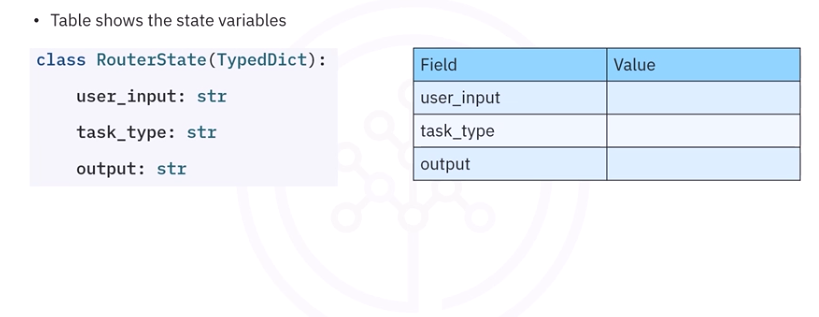

```python
from pydantic import BaseModel, Field

class Router(BaseModel):
    role: str = Field(description="...")

llm_router = llm.bind_tools([Router])

# nodes
def router_node(state: RouterState) -> RouterState:
    routing_prompt = f"""
    You are an AI task classifier.

    Decide wheterh the user want to:
    - "summarize" a passage
    - or "translate" text into French
    
    Respond with just one word: "summarize" or "translate".

    User Input: {state["user_input"]}
    """

    response = llm_router.invoke(routing_prompt)
    
    # Why do we need to pass the tool call in such a way?
    retur{**state, "task_type": response.tool_call[0]['args']['role']}

def router(state: RouterState) -> str:
    # the return act as a conditional node
    # since the state['task_type'] stores node names
    return state['task_type']

def summarize_node(state: RouterState) -> RouterState:
    prompt = f"""
    Please summarize the following passage: {state["user_input"]}
    """

    response = llm.invoke(prompt)
    return {**state, "task_type": "summarize", "output": response.content}

def translate_node(state: RouterState) -> RouterState:
    prompt = f"""
    Translate the following text to French: {state["user_input"]}
    """

    response = llm.invoke(prompt)
    return {**state, "task_type": "translate", "output": response.content}

# create workflow
# nodes
workflow = StateGraph(RouterState)
workflow.add_node(START, "router_node)
workflow.add_node("router_node", router_node)
workflow.add_node("summarize", summarize)
workflow.add_node("translate", translate_node)
workflow.add_node("summarize", END)
workflow.add_node("translate", END)

# conditional edge
workflow.add_conditional_edge(
    "router_node", 
    router,
    {
        "summarize": "summarize",
        "translate": "translate"
    }
)

app = workflow.compile()

input_text = {
    "user_input": "Can you translate this sentence: I love programming?"
}

result = app.invoke(input_text)
```

#### Parallelization pattern
- run multiple LLM tasks simultaneously
- boost speed and throughout

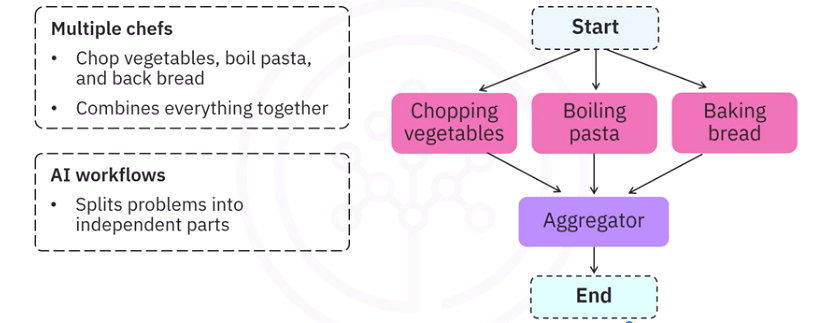

```python
class State(TypedDict):
    text: str
    french: str
    spanish: str
    japnnese: str
    combined_output: str

# nodes
# translation node for each language
def translate_fench(state: State) -> dict:
    response = llm.invoke(
        f"Translate to French: {state['text']}
    )
    return {"french": response.content.strip()}

def translate_spanish(state: State) -> dict:
    response = llm.invoke(
        f"Translate to French: {state['text']}
    )
    return {"french": response.content.strip()}

def translate_japanse(state: State) -> dict:
    response = llm.invoke(
        f"Translate to French: {state['text']}
    )
    return {"french": response.content.strip()}

def aggregator(state: State) -> dict:
    combined = f"Original Text: {state['text']} \n\n"
    combined += f"French: {state['french']}\n\n"
    combined += f"Spanish: {state['spanish']}\n\n"
    combined += f"Japanese: {state['japanese']}\n\n"

    return {"combined_output": combined}

# workflow
# nodes
graph = StateGraph(State)
graph.add_node("translate_french", translate_french)
graph.add_node("translate_spanish", translate_spanish)
graph.add_node("translate_japanise", translate_japanise)
graph.add_node("aggregator", aggregator)

# edges
graph.add_edge(START, "translate_french")
graph.add_edge(START, "translate_spanish")
graph.add_edge(START, "translate_japanise")
graph.add_edge("aggregator", END)

app = graph.compile()

input_text = {
    "text": "Good moringin! I hope you have a woderful day."
}

result = app.invoke(input_text)
```



### Orchastration Design Pattern

- orchestration (dymanic) manages dymanic workflows by breaking down complex requests tand assigning tasks to speciliyed worker agents

- **WorkerState** and shared **State** variables keep task-specific details and shared context seperate yet accessible for coordinated processing

- The assign workers node routes tasks in parallel, and each worker generates detailed outputs beased on structured inputs

- A syntesizer node combines all worker outputs into a unifed result, enableing flexible and scalable workflow execution.

```python
# example proxycode
# The Supervisor Node returns the name of the next agent
def supervisor_node(state: AgentState):
    # The LLM chooses one of the worker names or "FINISH"
    response = supervisor_llm.invoke(state["messages"])
    return {"next_agent": response.tool_calls[0].name} 

# 1. This is your Routing Logic (Not a node!)
def my_router_logic(state: State) -> str:
    # You can put complex 'if/else' logic here
    return state['task_type']

# The Graph Construction
builder = StateGraph(AgentState)
builder.add_node("coder", coder_node)
builder.add_node("tester", tester_node)
builder.add_node("supervisor", supervisor_node)

# ALL workers always report back to the supervisor
builder.add_edge("coder", "supervisor")
builder.add_edge("tester", "supervisor")

# The dynamic jump happens here
builder.add_conditional_edges(
    "supervisor",
    my_router_logic,
    {
        "coder": "coder",
        "tester": "tester",
        "finish": END
    }
)
```
- the supervisor can call any of the agents **dynamically**
- the task can be perfomed **parallel**, if the task is massive the supervisor can call multiple coders

- test prompt to supervisor: ```You are a manager. Given the user's request and the work done so far, who should work next: [Coder, Tester, Reviewer]? If the job is done, respond with FINISH```

- we can make the llm to output structured output to produce only ["coder", "tester", "finish"] in the output

```python
from pydantic import BaseModel
from typing import Literal

class Route(BaseModel):
    next_node: Literal["coder", "tester", "finish"]

# The LLM is now forced to return a Pydantic object
structured_llm = llm.with_structured_output(Route)

def supervisor_node(state: AgentState):
    decision = structured_llm.invoke(state["messages"])
    return {"next_node": decision.next_node} # Clean, validated string
```

- the above proxy code will run only in sequential